# 04. Where do the biases come from?

This notebook tests the hypotheses of the protocol, then checks that the results survive the robustness variants.

1. **H2, favorite-longshot bias**, on folded prices.
2. **A tick-size artifact**: can the 1-cent price floor create the bias mechanically?
3. **H3, cost of capital**, by horizon, with a bound on how large it could be.
4. **H4, liquidity and category**.
5. **Robustness**: bins, price definition, volume threshold, sub-periods.

**Provisional results**: validation sample of 10 events per series.

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pmcal.calibration import reliability_table
from pmcal.report import HORIZON_ORDER, stats, with_ci, fmt, fold

N_BOOT = int(os.environ.get("N_BOOT", 2000))  # protocol: 2,000 draws
MIN_VOLUME = 10_000

raw = pd.read_parquet(ROOT / "data" / "observations.parquet")
obs = raw[raw["volume_before"] >= MIN_VOLUME].copy()
obs["year"] = pd.to_datetime(obs["t"], unit="s").dt.year
print(f"Bootstrap draws: {N_BOOT:,}. {len(obs):,} observations in {obs['event_ticker'].nunique():,} events")

def beta_table(rows, keys):
    df = pd.DataFrame(rows)
    return pd.DataFrame({**{k: df[k] for k in keys}, "obs": df["n_obs"], "events": df["n_events"],
                         "beta [95% CI]": [fmt(r.beta, r.beta_lo, r.beta_hi) for r in df.itertuples()]})

Bootstrap draws: 2,000. 12,970 observations in 1,979 events


## 1. H2: favorite-longshot bias on folded prices

Each market is seen from its favorite: the price of the more likely side, and whether it won. If longshots are overpriced, favorites win **more often** than their price says. The table reports, for each favorite price bucket, the realized win rate minus the price, in percentage points.

In [2]:
folded = fold(obs)
bins = [0.5, 0.6, 0.7, 0.8, 0.9, 0.99, 1.0]
folded["bucket"] = pd.cut(folded["price"], bins, include_lowest=True)
edge = (folded.groupby(["horizon", "bucket"], observed=True)
        .apply(lambda g: pd.Series({"n": len(g), "edge_pp": 100 * (g["outcome"].mean() - g["price"].mean())}))
        .reset_index())
edge["horizon"] = pd.Categorical(edge["horizon"], HORIZON_ORDER, ordered=True)
edge.pivot(index="bucket", columns="horizon", values="edge_pp").round(1)

horizon,1h,1d,7d,30d
bucket,,,,
"(0.499, 0.6]",4.9,-2.1,-3.7,16.1
"(0.6, 0.7]",5.8,-0.4,3.8,3.7
"(0.7, 0.8]",3.1,-1.3,1.5,1.4
"(0.8, 0.9]",0.1,1.1,-2.3,2.2
"(0.9, 0.99]",1.3,0.8,1.2,0.2
"(0.99, 1.0]",0.2,0.2,0.2,0.2


In [3]:
rows = [with_ci(folded[folded["horizon"] == h], N_BOOT, horizon=h) for h in HORIZON_ORDER if (folded["horizon"] == h).any()]
beta_table(rows, ["horizon"])

,horizon,obs,events,beta [95% CI]
0,1h,6935,1596,"1.33 [1.23, 1.45]"
1,1d,3803,978,"1.14 [1.02, 1.29]"
2,7d,1591,370,"1.12 [0.97, 1.31]"
3,30d,641,156,"0.98 [0.79, 1.23]"


## 2. A tick-size artifact?

Most Kalshi markets trade in whole cents, so the lowest possible Yes price is 0.01. A market that is almost certainly lost (a temperature bracket already exceeded, an hour before close) cannot trade below that floor, even if its true probability is 0.001. Longshots then look overpriced for purely mechanical reasons.

Test: how often do markets at the floor win, and does the bias survive once prices at the extremes are removed?

In [4]:
at_floor = obs["price"] <= 0.01
at_cap = obs["price"] >= 0.99
floor = pd.DataFrame({
    "share at <= 0.01": obs.groupby("horizon")["price"].apply(lambda s: (s <= 0.01).mean()),
    "win rate at <= 0.01": obs[at_floor].groupby("horizon")["outcome"].mean(),
    "share at >= 0.99": obs.groupby("horizon")["price"].apply(lambda s: (s >= 0.99).mean()),
    "win rate at >= 0.99": obs[at_cap].groupby("horizon")["outcome"].mean(),
}).reindex(HORIZON_ORDER)
floor.style.format("{:.1%}")

,share at <= 0.01,win rate at <= 0.01,share at >= 0.99,win rate at >= 0.99
horizon,,,,
1h,41.5%,0.0%,18.1%,99.7%
1d,20.2%,0.0%,7.9%,99.3%
7d,14.1%,0.0%,5.3%,100.0%
30d,12.9%,0.0%,1.7%,100.0%


In [5]:
rows = []
for h in HORIZON_ORDER:
    d = obs[obs["horizon"] == h]
    if d.empty:
        continue
    rows.append(with_ci(d, N_BOOT, horizon=h, prices="all"))
    rows.append(with_ci(d[(d["price"] > 0.02) & (d["price"] < 0.98)], N_BOOT, horizon=h, prices="0.02 < p < 0.98"))
tick = beta_table(rows, ["horizon", "prices"])
tick

,horizon,prices,obs,events,beta [95% CI]
0,1h,all,6935,1596,"1.29 [1.21, 1.39]"
1,1h,0.02 < p < 0.98,2135,710,"1.19 [1.09, 1.32]"
2,1d,all,3803,978,"1.07 [0.98, 1.18]"
3,1d,0.02 < p < 0.98,2355,867,"1.02 [0.92, 1.12]"
4,7d,all,1591,370,"1.08 [0.97, 1.22]"
5,7d,0.02 < p < 0.98,1088,324,"1.05 [0.94, 1.20]"
6,30d,all,641,156,"1.07 [0.92, 1.30]"
7,30d,0.02 < p < 0.98,453,145,"1.02 [0.83, 1.29]"


## 3. H3: cost of capital

Buying the favorite at price p and waiting T years for 1 dollar ties up p dollars. If cash earns a rate r elsewhere, a rational buyer tolerates a mispricing of about p × r × T before acting. The table gives this bound at 4% a year. It is tiny at our horizons: the cost of capital cannot explain a large bias at 30 days or less.

On top of this, Kalshi pays interest on the value of open positions to eligible US users, which shrinks the cost of capital further. H3 is therefore expected to be weak on Kalshi.

In [6]:
r = 0.04
days = {"1h": 1 / 24, "1d": 1, "7d": 7, "30d": 30}
bound = pd.DataFrame({f"favorite at {p:.2f}": {h: 100 * p * r * days[h] / 365 for h in HORIZON_ORDER}
                      for p in [0.80, 0.90, 0.97]})
print("Largest mispricing explained by the cost of capital, in percentage points")
bound.round(3)

Largest mispricing explained by the cost of capital, in percentage points


,favorite at 0.80,favorite at 0.90,favorite at 0.97
1h,0.000,0.000,0.000
1d,0.009,0.010,0.011
7d,0.061,0.069,0.074
30d,0.263,0.296,0.319


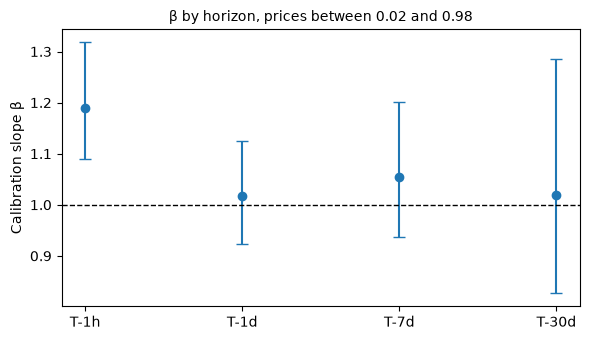

In [7]:
d = pd.DataFrame(rows)
d = d[d["prices"] == "0.02 < p < 0.98"]
fig, ax = plt.subplots(figsize=(6, 3.5))
x = np.arange(len(d))
ax.errorbar(x, d["beta"], yerr=[d["beta"] - d["beta_lo"], d["beta_hi"] - d["beta"]], fmt="o", capsize=4)
ax.axhline(1, color="k", ls="--", lw=1)
ax.set_xticks(x, [f"T-{h}" for h in d["horizon"]])
ax.set_ylabel("Calibration slope β")
ax.set_title("β by horizon, prices between 0.02 and 0.98", fontsize=10)
plt.tight_layout()
fig.savefig(ROOT / "figures" / "beta_by_horizon_interior.png", dpi=150)
plt.show()

## 4. H4: liquidity and category

Volume buckets use the contracts traded before the horizon. Prices at the extremes are removed, so that the tick floor does not drive the comparison.

In [8]:
interior = obs[(obs["price"] > 0.02) & (obs["price"] < 0.98)].copy()
interior["volume_bucket"] = pd.cut(interior["volume_before"], [1e4, 5e4, 5e5, np.inf],
                                   labels=["10k to 50k", "50k to 500k", "over 500k"], right=False)
rows = [with_ci(g, N_BOOT, volume=str(v)) for v, g in interior.groupby("volume_bucket", observed=True)]
beta_table(rows, ["volume"])

,volume,obs,events,beta [95% CI]
0,10k to 50k,3621,1029,"1.08 [0.99, 1.18]"
1,50k to 500k,2002,534,"1.04 [0.90, 1.22]"
2,over 500k,408,115,"1.40 [1.14, 1.87]"


In [9]:
rows = []
for fam, g in interior.groupby("family"):
    if g["event_ticker"].nunique() >= 20:
        rows.append(with_ci(g, N_BOOT, family=fam))
print("Families with at least 20 events, all horizons pooled")
beta_table(rows, ["family"])

Families with at least 20 events, all horizons pooled


,family,obs,events,beta [95% CI]
0,culture,1102,202,"1.08 [0.92, 1.31]"
1,economics,3852,503,"1.08 [0.97, 1.20]"
2,sports,801,359,"1.08 [0.87, 1.34]"
3,weather,240,124,"1.15 [0.87, 1.57]"


## 5. Robustness

Every variant of the protocol, on the main horizon (T-1d) and on T-1h, with prices between 0.02 and 0.98.

In [10]:
def variants(h):
    base = raw[(raw["horizon"] == h) & (raw["price"] > 0.02) & (raw["price"] < 0.98)].copy()
    base["year"] = pd.to_datetime(base["t"], unit="s").dt.year
    main = base[base["volume_before"] >= MIN_VOLUME]
    out = {
        "main specification": main,
        "volume >= 1,000": base[base["volume_before"] >= 1_000],
        "volume >= 100,000": base[base["volume_before"] >= 100_000],
        "midpoint prices only": main[main["price_source"] == "mid"],
        "last-trade prices only": main[main["price_source"] == "last"],
        "2024 and earlier": main[main["year"] <= 2024],
        "2025": main[main["year"] == 2025],
        "2026": main[main["year"] == 2026],
    }
    return out

rows = []
for h in ["1d", "1h"]:
    for name, d in variants(h).items():
        if d["event_ticker"].nunique() >= 20:
            rows.append(with_ci(d, N_BOOT, horizon=h, variant=name))
        else:
            rows.append({"horizon": h, "variant": name, "n_obs": len(d), "n_events": d["event_ticker"].nunique(),
                         "beta": np.nan, "beta_lo": np.nan, "beta_hi": np.nan})
robust = beta_table(rows, ["horizon", "variant"])
robust

,horizon,variant,obs,events,beta [95% CI]
0,1d,main specification,2355,867,"1.02 [0.92, 1.12]"
1,1d,"volume >= 1,000",7342,2221,"0.98 [0.92, 1.05]"
2,1d,"volume >= 100,000",595,269,"1.14 [0.93, 1.39]"
3,1d,midpoint prices only,2232,837,"1.03 [0.94, 1.15]"
4,1d,last-trade prices only,123,91,"0.85 [0.65, 1.20]"
5,1d,2024 and earlier,361,139,"1.06 [0.89, 1.30]"
6,1d,2025,526,210,"0.90 [0.71, 1.13]"
7,1d,2026,1468,518,"1.06 [0.94, 1.22]"
8,1h,main specification,2135,710,"1.19 [1.09, 1.32]"
9,1h,"volume >= 1,000",3810,1154,"1.19 [1.11, 1.28]"


In [11]:
d = pd.DataFrame([r for r in rows if r["horizon"] == "1d"])
quant = with_ci(obs[obs["horizon"] == "1d"], N_BOOT,
                stat_fn=lambda x: stats(x, strategy="quantile"), horizon="1d", variant="quantile bins")
unif = with_ci(obs[obs["horizon"] == "1d"], N_BOOT, horizon="1d", variant="fixed-width bins")
print("REL at T-1d, fixed-width against quantile bins (β does not depend on the bins)")
pd.DataFrame([unif, quant])[["variant", "REL", "REL_lo", "REL_hi"]].round(4)

REL at T-1d, fixed-width against quantile bins (β does not depend on the bins)


,variant,REL,REL_lo,REL_hi
0,fixed-width bins,0.0002,0.0002,0.0015
1,quantile bins,0.0002,0.0001,0.0012


## 6. Export

In [12]:
tick.to_csv(ROOT / "data" / "results_tick.csv", index=False)
robust.to_csv(ROOT / "data" / "results_robustness.csv", index=False)
print("Saved")

Saved
